In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import keras
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [184]:
df = pd.read_csv(r"../data/cleaned/cleaned.csv")

In [185]:
df = df.drop(columns=['Unnamed: 0'])
df

,Datetime,PJME_MW,year,month,hour,day_num,day_of_month,week_of_year,is_weekend,lag_1,lag_24,lag_168,rolling_mean_24,rolling_std_24
0,2002-01-09 01:00:00,29082.0,2002,1,1,2,9,2,0,30943.0,29445.0,28121.0,34352.750000,3579.227464
1,2002-01-09 02:00:00,28154.0,2002,1,2,2,9,2,0,29082.0,28670.0,27437.0,34337.625000,3601.565467
2,2002-01-09 03:00:00,27829.0,2002,1,3,2,9,2,0,28154.0,28375.0,27301.0,34316.125000,3638.223698
3,2002-01-09 04:00:00,27759.0,2002,1,4,2,9,2,0,27829.0,28542.0,27533.0,34293.375000,3678.473523
4,2002-01-09 05:00:00,28308.0,2002,1,5,2,9,2,0,27759.0,29261.0,28405.0,34260.750000,3734.743158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145195,2018-08-02 20:00:00,44057.0,2018,8,20,3,2,31,0,45641.0,46912.0,46337.0,40021.875000,6475.317097
145196,2018-08-02 21:00:00,43256.0,2018,8,21,3,2,31,0,44057.0,45985.0,44542.0,39902.916667,6368.579836
145197,2018-08-02 22:00:00,41552.0,2018,8,22,3,2,31,0,43256.0,44094.0,42638.0,39789.208333,6278.997878
145198,2018-08-02 23:00:00,38500.0,2018,8,23,3,2,31,0,41552.0,40666.0,39276.0,39683.291667,6224.428358


In [186]:
#date time conversion

In [187]:
df['Datetime'] = df['Datetime'].astype('datetime64[ms]')

In [188]:
df = df.sort_values('Datetime').reset_index(drop=True)

In [189]:
time_diff = df['Datetime'].diff()
time_diff

0                    NaT
1        0 days 01:00:00
2        0 days 01:00:00
3        0 days 01:00:00
4        0 days 01:00:00
               ...      
145195   0 days 01:00:00
145196   0 days 01:00:00
145197   0 days 01:00:00
145198   0 days 01:00:00
145199   0 days 01:00:00
Name: Datetime, Length: 145200, dtype: timedelta64[ms]

In [190]:
#test dataset

In [191]:
n = len(df)

test_size = int(n * 0.20)

test_start = n - test_size

test_start

116160

In [192]:
#validation dataset

In [193]:
validation_end = test_start

validation_start_date = (df.loc[validation_end, 'Datetime']- pd.Timedelta(days=60))

validation_start = df['Datetime'].searchsorted(validation_start_date)

In [194]:
# spliting 3 dataset

In [195]:
df_train = df.iloc[:validation_start].copy()

df_val = df.iloc[validation_start:validation_end].copy()

df_test = df.iloc[validation_end:].copy()

In [196]:
print(len(df_train))

print(len(df_val))

print(len(df_test))

114720
1440
29040


In [197]:
df_train

,Datetime,PJME_MW,year,month,hour,day_num,day_of_month,week_of_year,is_weekend,lag_1,lag_24,lag_168,rolling_mean_24,rolling_std_24
0,2002-01-09 01:00:00,29082.0,2002,1,1,2,9,2,0,30943.0,29445.0,28121.0,34352.750000,3579.227464
1,2002-01-09 02:00:00,28154.0,2002,1,2,2,9,2,0,29082.0,28670.0,27437.0,34337.625000,3601.565467
2,2002-01-09 03:00:00,27829.0,2002,1,3,2,9,2,0,28154.0,28375.0,27301.0,34316.125000,3638.223698
3,2002-01-09 04:00:00,27759.0,2002,1,4,2,9,2,0,27829.0,28542.0,27533.0,34293.375000,3678.473523
4,2002-01-09 05:00:00,28308.0,2002,1,5,2,9,2,0,27759.0,29261.0,28405.0,34260.750000,3734.743158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114715,2015-02-09 20:00:00,40458.0,2015,2,20,0,9,7,0,41107.0,34160.0,42465.0,34025.750000,4733.579712
114716,2015-02-09 21:00:00,39406.0,2015,2,21,0,9,7,0,40458.0,33529.0,41789.0,34288.166667,4912.534922
114717,2015-02-09 22:00:00,37578.0,2015,2,22,0,9,7,0,39406.0,32207.0,40172.0,34533.041667,5018.382465
114718,2015-02-09 23:00:00,35044.0,2015,2,23,0,9,7,0,37578.0,30506.0,37764.0,34756.833333,5029.889165


In [198]:
#input target

In [199]:
feature_cols = ['PJME_MW','year','month','hour','day_num','day_of_month','week_of_year','is_weekend',
                'lag_1','lag_24','lag_168','rolling_mean_24','rolling_std_24']

target_col = 'PJME_MW'

In [200]:
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

In [201]:
X_train = feature_scaler.fit_transform(df_train[feature_cols])
y_train = target_scaler.fit_transform(df_train[[target_col]])

In [202]:
X_val = feature_scaler.transform(df_val[feature_cols])

y_val= target_scaler.transform(df_val[[target_col]])

In [203]:
X_test= feature_scaler.transform(df_test[feature_cols])

y_test= target_scaler.transform(df_test[[target_col]])

In [204]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (114720, 13)
y_train: (114720, 1)
X_val: (1440, 13)
y_val: (1440, 1)
X_test: (29040, 13)
y_test: (29040, 1)


In [205]:
SEQ_LEN = 24
HORIZON = 24

In [206]:
def create_sequences(X, y, seq_len=24, horizon=24):

    X_seq = []
    y_seq = []

    for i in range(len(X) - seq_len - horizon + 1):

        X_seq.append(X[i:i + seq_len])

        y_seq.append(y[i + seq_len:i + seq_len + horizon])

    return np.array(X_seq), np.array(y_seq)

In [207]:
X_train_seq, y_train_seq = create_sequences(X_train,y_train,SEQ_LEN,HORIZON)
X_val_seq, y_val_seq = create_sequences(X_val,y_val,SEQ_LEN,HORIZON)
X_test_seq, y_test_seq = create_sequences(X_test,y_test,SEQ_LEN,HORIZON)

In [208]:
print("X_train_seq:", X_train_seq.shape)
print("y_train_seq:", y_train_seq.shape)

print("X_val_seq:", X_val_seq.shape)
print("y_val_seq:", y_val_seq.shape)

print("X_test_seq:", X_test_seq.shape)
print("y_test_seq:", y_test_seq.shape)

X_train_seq: (114673, 24, 13)
y_train_seq: (114673, 24, 1)
X_val_seq: (1393, 24, 13)
y_val_seq: (1393, 24, 1)
X_test_seq: (28993, 24, 13)
y_test_seq: (28993, 24, 1)


In [209]:
y_train_seq = y_train_seq.squeeze(-1)
y_val_seq = y_val_seq.squeeze(-1)
y_test_seq = y_test_seq.squeeze(-1)

In [210]:
print(y_train_seq.shape)
print(y_val_seq.shape)
print(y_test_seq.shape)

(114673, 24)
(1393, 24)
(28993, 24)


In [211]:
model = keras.models.load_model(r'../models/gru_16.keras')

In [212]:
y_pred_val_scaled = model.predict(X_val_seq)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [243]:

y_pred_val_mw = target_scaler.inverse_transform(y_pred_val_scaled.reshape(-1, 1)).reshape(y_pred_val_scaled.shape)

y_val_mw = target_scaler.inverse_transform(y_val_seq.reshape(-1, 1)).reshape(y_val_seq.shape)

In [242]:
len(y_val_mw)

1393

In [214]:
#30 day forecast

In [244]:
actual_30 = y_val_mw[:720]
predicted_30 = y_pred_val_mw[:720]

In [245]:
actual_30.ravel()

array([31272., 30698., 30641., ..., 33137., 32042., 30360.],
      shape=(17280,))

In [246]:
mae_30 = mean_absolute_error(actual_30,predicted_30)

rmse_30 = np.sqrt(mean_squared_error(actual_30,predicted_30))

mape_30 = np.mean(np.abs((actual_30 - predicted_30) /actual_30)) * 100

r2_30 = r2_score(actual_30,predicted_30)


print(f"MAE  : {mae_30:.2f} MW")
print(f"RMSE : {rmse_30:.2f} MW")
print(f"MAPE : {mape_30:.2f}%")
print(f"R²   : {r2_30:.4f}")

MAE  : 1909.67 MW
RMSE : 2632.73 MW
MAPE : 5.10%
R²   : 0.7092


In [217]:
#60 days forecast

In [249]:
mae = mean_absolute_error(y_val_mw,y_pred_val_mw)

rmse = np.sqrt(mean_squared_error(y_val_mw,y_pred_val_mw))

mape = np.mean(np.abs((y_val_mw - y_pred_val_mw) /y_val_mw)) * 100

r2 = r2_score(y_val_mw,y_pred_val_mw)


print(f"MAE  : {mae:.2f} MW")
print(f"RMSE : {rmse:.2f} MW")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")

MAE  : 1595.84 MW
RMSE : 2220.69 MW
MAPE : 4.68%
R²   : 0.8413


In [219]:
#visulaization

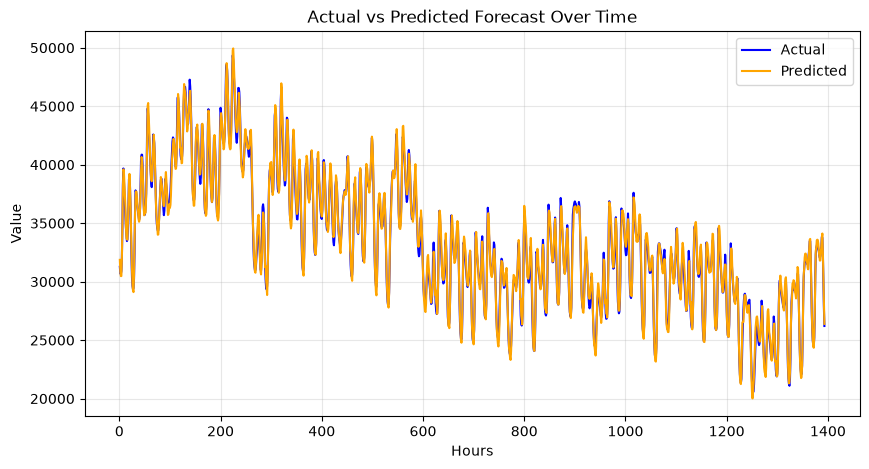

In [260]:
plt.figure(figsize=(10, 5))
sns.lineplot(data = df ,x='Date', y='Actual', label='Actual', color='blue')
sns.lineplot(data = df ,x='Date',y='Predicted',label='Predicted',color='orange')

plt.title('Actual vs Predicted Forecast Over Time')
plt.xlabel('Hours')
plt.ylabel('Value')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


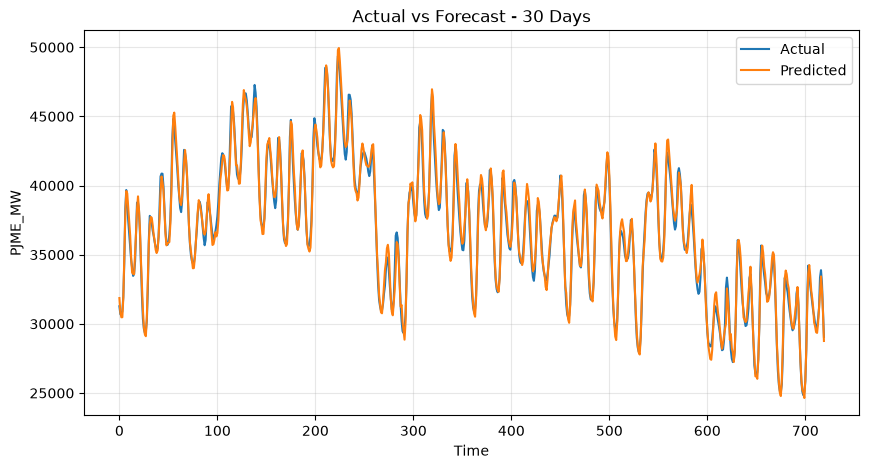

In [263]:
plt.figure(figsize=(10, 5))

plt.plot(y_val_mw[:720, 0],label="Actual")

plt.plot(y_pred_val_mw[:720, 0],label="Predicted")

plt.title("Actual vs Forecast - 30 Days")
plt.xlabel("Time")
plt.ylabel("PJME_MW")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
#daily error

In [268]:
complete_hours = (
    len(actual_30) // 24
) * 24

daily_mae = np.abs(
    actual_30[:complete_hours]
    - predicted_30[:complete_hours]
).reshape(-1, 24).mean(axis=1)

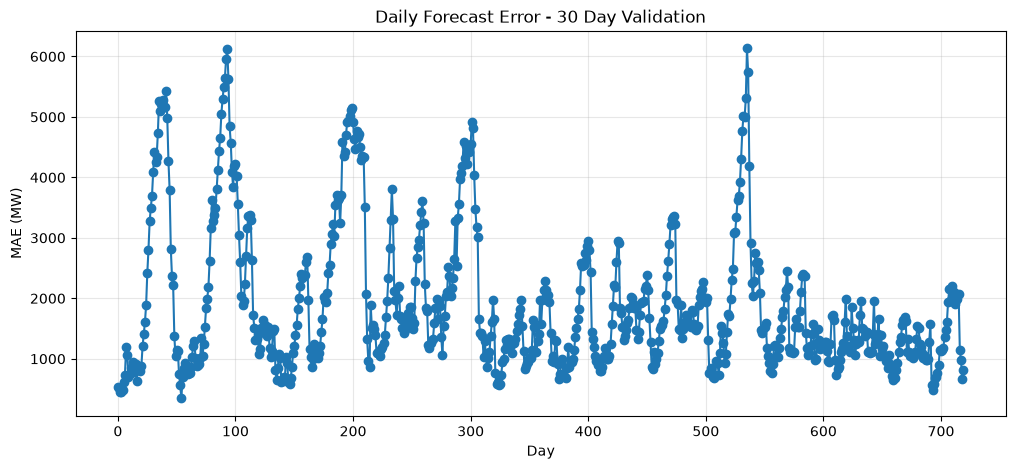

In [274]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_mae,
    marker="o"
)

plt.title(
    "Daily Forecast Error - 30 Day Validation"
)

plt.xlabel("Day")

plt.ylabel("MAE (MW)")

plt.grid(alpha=0.3)

plt.show()

In [276]:
actual_peak = []
predicted_peak = []

for i in range(0, len(actual_30), 24):

    day_actual = actual_30[i:i+24]
    day_pred = predicted_30[i:i+24]

    actual_peak.append(np.max(day_actual))
    predicted_peak.append(np.max(day_pred))

peak_error = np.array(actual_peak) - np.array(predicted_peak)

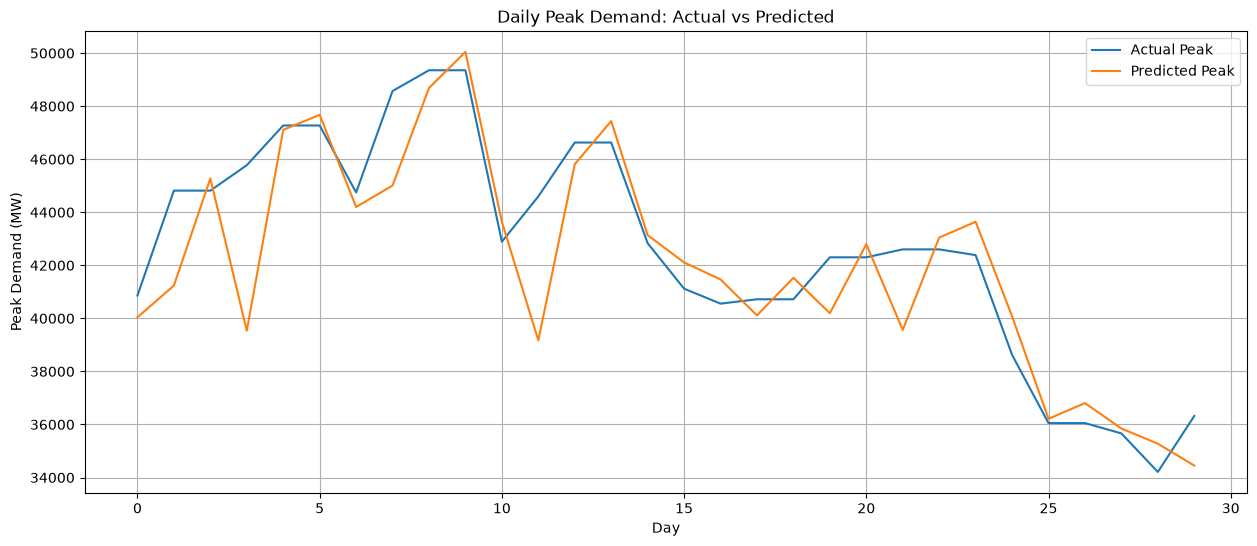

In [277]:
plt.figure(figsize=(15, 6))

plt.plot(
    actual_peak,
    label="Actual Peak"
)

plt.plot(
    predicted_peak,
    label="Predicted Peak"
)

plt.title("Daily Peak Demand: Actual vs Predicted")
plt.xlabel("Day")
plt.ylabel("Peak Demand (MW)")
plt.legend()
plt.grid(True)

plt.show()

In [284]:
errors = actual_30 - predicted_30

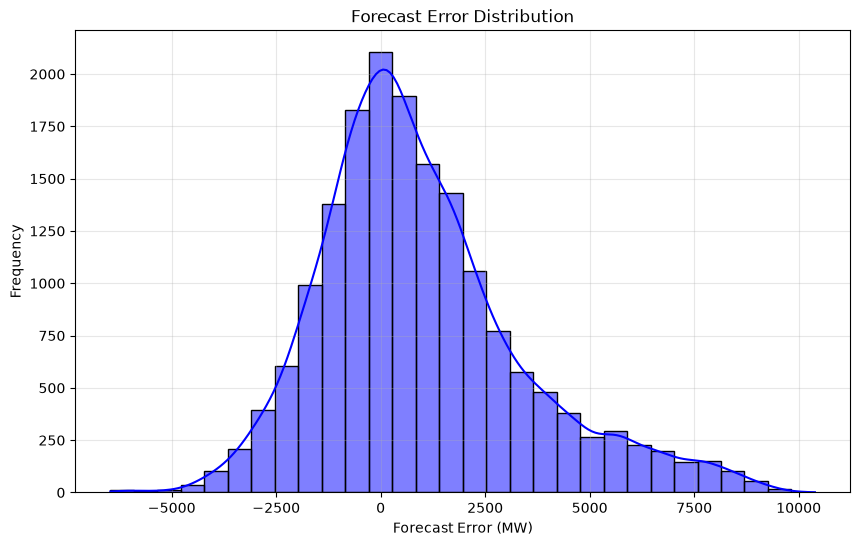

In [291]:
plt.figure(figsize=(10, 6))

sns.histplot(errors.ravel(),bins=30,color='blue',kde=True)

plt.title("Forecast Error Distribution")
plt.xlabel("Forecast Error (MW)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

plt.show()